In [1]:
import pandas as pd

# Load each yearly file separately first, since column names differ year to year
files = {
    2015: '2015.csv', 2016: '2016.csv', 2017: '2017.csv', 2018: '2018.csv',
    2019: '2019.csv', 2020: '2020.csv', 2021: '2021.csv', 2022: '2022.csv',
}

raw_frames = {year: pd.read_csv(f'../data/raw/{fname}') for year, fname in files.items()}

for year, df in raw_frames.items():
    print(f"--- {year} ---")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print()

--- 2015 ---
shape: (158, 12)
columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2016 ---
shape: (157, 13)
columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2017 ---
shape: (155, 12)
columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

--- 2018 ---
shape: (156, 9)
columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life c

In [2]:
# Standardize each year's messy column names onto one common schema
rename_maps = {
    2015: {'Country':'country','Region':'region','Happiness Score':'happiness_score',
           'Economy (GDP per Capita)':'gdp_per_capita','Family':'social_support',
           'Health (Life Expectancy)':'life_expectancy','Freedom':'freedom',
           'Trust (Government Corruption)':'corruption','Generosity':'generosity'},
    2016: {'Country':'country','Region':'region','Happiness Score':'happiness_score',
           'Economy (GDP per Capita)':'gdp_per_capita','Family':'social_support',
           'Health (Life Expectancy)':'life_expectancy','Freedom':'freedom',
           'Trust (Government Corruption)':'corruption','Generosity':'generosity'},
    2017: {'Country':'country','Happiness.Score':'happiness_score',
           'Economy..GDP.per.Capita.':'gdp_per_capita','Family':'social_support',
           'Health..Life.Expectancy.':'life_expectancy','Freedom':'freedom',
           'Trust..Government.Corruption.':'corruption','Generosity':'generosity'},
    2018: {'Country or region':'country','Score':'happiness_score',
           'GDP per capita':'gdp_per_capita','Social support':'social_support',
           'Healthy life expectancy':'life_expectancy','Freedom to make life choices':'freedom',
           'Perceptions of corruption':'corruption','Generosity':'generosity'},
    2019: {'Country or region':'country','Score':'happiness_score',
           'GDP per capita':'gdp_per_capita','Social support':'social_support',
           'Healthy life expectancy':'life_expectancy','Freedom to make life choices':'freedom',
           'Perceptions of corruption':'corruption','Generosity':'generosity'},
    2020: {'Country name':'country','Regional indicator':'region','Ladder score':'happiness_score',
           'Logged GDP per capita':'gdp_per_capita','Social support':'social_support',
           'Healthy life expectancy':'life_expectancy','Freedom to make life choices':'freedom',
           'Perceptions of corruption':'corruption','Generosity':'generosity'},
    2021: {'Country name':'country','Regional indicator':'region','Ladder score':'happiness_score',
           'Logged GDP per capita':'gdp_per_capita','Social support':'social_support',
           'Healthy life expectancy':'life_expectancy','Freedom to make life choices':'freedom',
           'Perceptions of corruption':'corruption','Generosity':'generosity'},
    2022: {'Country':'country','Happiness score':'happiness_score',
           'Explained by: GDP per capita':'gdp_per_capita','Explained by: Social support':'social_support',
           'Explained by: Healthy life expectancy':'life_expectancy',
           'Explained by: Freedom to make life choices':'freedom',
           'Explained by: Perceptions of corruption':'corruption','Explained by: Generosity':'generosity'},
}

keep_cols = ['country','region','happiness_score','gdp_per_capita','social_support',
             'life_expectancy','freedom','generosity','corruption']

frames = []
for year, df in raw_frames.items():
    df = df.rename(columns=rename_maps[year])
    for c in keep_cols:
        if c not in df.columns:
            df[c] = pd.NA
    df = df[keep_cols].copy()
    df['year'] = year
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
print("Combined shape:", combined.shape)
combined.head()

Combined shape: (1231, 10)


,country,region,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.4363,0.14145,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,7.522,1.459,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


In [3]:
print("Shape:", combined.shape)
print()
print("Dtypes:")
print(combined.dtypes)
print()
print("Null counts:")
print(combined.isna().sum())
print()
print("Unique counts:")
print(combined.nunique())

Shape: (1231, 10)

Dtypes:
country               str
region             object
happiness_score    object
gdp_per_capita     object
social_support     object
life_expectancy    object
freedom            object
generosity         object
corruption         object
year                int64
dtype: object

Null counts:
country              0
region             614
happiness_score      1
gdp_per_capita       1
social_support       1
life_expectancy      1
freedom              1
generosity           1
corruption           2
year                 0
dtype: int64

Unique counts:
country             196
region               16
happiness_score    1132
gdp_per_capita     1183
social_support     1116
life_expectancy    1124
freedom            1096
generosity         1034
corruption         1031
year                  8
dtype: int64


In [4]:
def is_not_numeric(v):
    try:
        float(v)
        return False
    except:
        return True

mask = combined['happiness_score'].apply(is_not_numeric)
print("Non-numeric happiness_score entries:", mask.sum())
combined.loc[mask, ['country','year','happiness_score']].head()

Non-numeric happiness_score entries: 146


,country,year,happiness_score
1084,Finland,2022,"7,821"
1085,Denmark,2022,"7,636"
1086,Iceland,2022,"7,557"
1087,Switzerland,2022,"7,512"
1088,Netherlands,2022,"7,415"


In [5]:
# Fix: 2022's file uses comma decimals ("7,821") instead of periods, which forced
# pandas to read these columns as text. Convert them properly to numeric.
numeric_cols = ['happiness_score','gdp_per_capita','social_support',
                'life_expectancy','freedom','generosity','corruption']

for col in numeric_cols:
    combined[col] = combined[col].astype(str).str.replace(',', '.', regex=False)
    combined[col] = pd.to_numeric(combined[col], errors='coerce')

print(combined.dtypes)
print()
print("Nulls after numeric conversion:")
print(combined.isna().sum())

# Found later, while charting: 2020/2021 source files used "Logged GDP per capita"
# (log scale, ~6-11), while every other year used a pre-normalized index (~0-2).
# These are fundamentally different metrics, not convertible into each other.
# Flag them as missing rather than mixing incompatible units into one column silently.
combined.loc[combined['year'].isin([2020, 2021]), 'gdp_per_capita'] = pd.NA
print()
print("GDP per capita nulls after flagging 2020/2021:", combined['gdp_per_capita'].isna().sum())

country                str
region              object
happiness_score    float64
gdp_per_capita     float64
social_support     float64
life_expectancy    float64
freedom            float64
generosity         float64
corruption         float64
year                 int64
dtype: object

Nulls after numeric conversion:
country              0
region             614
happiness_score      1
gdp_per_capita       1
social_support       1
life_expectancy      1
freedom              1
generosity           1
corruption           2
year                 0
dtype: int64

GDP per capita nulls after flagging 2020/2021: 303


In [6]:
# Build a country -> region lookup from years that have it (2015, 2016, 2020, 2021)
region_lookup = (
    combined.dropna(subset=['region'])
      .drop_duplicates(subset=['country'])
      [['country','region']]
      .rename(columns={'region':'region_lookup'})
)
print("Lookup table rows:", region_lookup.shape)

print("Shape before merge:", combined.shape)
combined = combined.merge(region_lookup, on='country', how='left')
print("Shape after merge:", combined.shape)

combined['region'] = combined['region'].fillna(combined['region_lookup'])
combined = combined.drop(columns=['region_lookup'])

print("Still missing region after merge:", combined['region'].isna().sum())
print(sorted(combined.loc[combined['region'].isna(), 'country'].unique()))

Lookup table rows: (169, 2)
Shape before merge: (1231, 10)
Shape after merge: (1231, 11)
Still missing region after merge: 29
['Azerbaijan*', 'Belarus*', 'Botswana*', 'Chad*', 'Comoros*', 'Congo', 'Czechia', 'Eswatini, Kingdom of*', 'Gambia*', 'Guatemala*', 'Hong Kong S.A.R., China', 'Kuwait*', 'Lesotho*', 'Liberia*', 'Libya*', 'Luxembourg*', 'Madagascar*', 'Mauritania*', 'Niger*', 'North Cyprus*', 'Northern Cyprus', 'Palestinian Territories*', 'Rwanda*', 'Trinidad & Tobago', 'Turkmenistan*', 'Yemen*', 'xx']


In [7]:
# Drop the junk row from the 2022 source file (no real country, no real data)
before = combined.shape[0]
combined = combined[combined['country'].astype(str).str.strip() != 'xx']
print(f"Dropped {before - combined.shape[0]} junk row(s)")

# Fix the join key: strip trailing asterisks, normalize renamed countries
combined['country'] = combined['country'].astype(str).str.strip().str.rstrip('*').str.strip()

alias_map = {
    'Trinidad & Tobago': 'Trinidad and Tobago',
    'Northern Cyprus': 'North Cyprus',
    'Hong Kong S.A.R., China': 'Hong Kong',
    'Czechia': 'Czech Republic',
    'Eswatini, Kingdom of': 'Swaziland',
}
combined['country'] = combined['country'].replace(alias_map)

# Rebuild the lookup now that names are clean, and merge again
region_lookup = (
    combined.dropna(subset=['region'])
      .drop_duplicates(subset=['country'])
      [['country','region']]
      .rename(columns={'region':'region_lookup'})
)

combined = combined.drop(columns=[c for c in ['region_lookup'] if c in combined.columns])
combined = combined.merge(region_lookup, on='country', how='left')
combined['region'] = combined['region'].fillna(combined['region_lookup'])
combined = combined.drop(columns=['region_lookup'])

print("Still missing region:", combined['region'].isna().sum())
print(sorted(combined.loc[combined['region'].isna(), 'country'].unique()))

Dropped 1 junk row(s)
Still missing region: 1
['Congo']


In [8]:
# Both Congo variants across other years fall in the same region, so we can fill
# this last holdout directly rather than guess which specific Congo it refers to
combined.loc[combined['country']=='Congo', 'region'] = 'Sub-Saharan Africa'

print("Remaining missing region:", combined['region'].isna().sum())
print("Shape:", combined.shape)

Remaining missing region: 0
Shape: (1230, 10)


In [9]:
# Check what's left missing among the numeric columns
print(combined.isna().sum())
print()
print(combined[combined.isna().any(axis=1)][['country','year']])

country              0
region               0
happiness_score      0
gdp_per_capita     302
social_support       0
life_expectancy      0
freedom              0
generosity           0
corruption           1
year                 0
dtype: int64

                   country  year
489   United Arab Emirates  2018
782                Finland  2020
783                Denmark  2020
784            Switzerland  2020
785                Iceland  2020
...                    ...   ...
1079               Lesotho  2021
1080              Botswana  2021
1081                Rwanda  2021
1082              Zimbabwe  2021
1083           Afghanistan  2021

[303 rows x 2 columns]


In [10]:
# Missing value: only 1 row missing 'corruption' (UAE, 2018) out of 1230 rows.
# Impute using that country's OWN mean across its other years, rather than a global
# average across very different countries - a single missing value has tiny impact
# either way, but this keeps the fill realistic for that specific country.
uae_mean = combined.loc[combined['country']=='United Arab Emirates', 'corruption'].mean()
combined['corruption'] = combined['corruption'].fillna(uae_mean)
print("UAE's own mean used for imputation:", round(uae_mean, 4))
print("Remaining nulls total:", combined.isna().sum().sum())
print()

# Duplicates: check both exact row duplicates and duplicate (country, year) pairs -
# a real duplicate here would mean the same country's data was double-counted for a year
print("Exact duplicate rows:", combined.duplicated().sum())
print("Duplicate (country, year) pairs:", combined.duplicated(subset=['country','year']).sum())

UAE's own mean used for imputation: 0.3831
Remaining nulls total: 302

Exact duplicate rows: 0
Duplicate (country, year) pairs: 0


## Task 3 — Feature Engineering with GroupBy and Merge

I already did one merge in Task 2 (the region lookup). Now I added a groupby aggregation to compute per-region statistics and merge them back onto the main dataframe.

In [11]:
print("Shape before groupby transform:", combined.shape)

# GroupBy: average happiness score and average GDP per capita, per region and year.
# Useful because a country's raw score means little on its own - comparing it to its
# region's average for that year reveals whether a country is punching above or below
# its neighbors, which a single-row view can't show.
region_year_stats = combined.groupby(['region', 'year'], observed=True).agg(
    region_avg_happiness=('happiness_score', 'mean'),
    region_avg_gdp=('gdp_per_capita', 'mean'),
).reset_index()

combined = combined.merge(region_year_stats, on=['region', 'year'], how='left')
print("Shape after groupby+merge:", combined.shape)

# How far each country sits above/below its own region's average that year
combined['happiness_vs_region'] = combined['happiness_score'] - combined['region_avg_happiness']

region_year_stats.head(10)

Shape before groupby transform: (1230, 10)
Shape after groupby+merge: (1230, 12)


,region,year,region_avg_happiness,region_avg_gdp
0,Australia and New Zealand,2015,7.285000,1.291880
1,Australia and New Zealand,2016,7.323500,1.402545
2,Australia and New Zealand,2017,7.299000,1.445060
3,Australia and New Zealand,2018,7.298000,1.304000
4,Australia and New Zealand,2019,7.267500,1.337500
5,Australia and New Zealand,2022,7.181000,1.876000
6,Central and Eastern Europe,2015,5.332931,0.942438
7,Central and Eastern Europe,2016,5.370690,1.047537
8,Central and Eastern Europe,2017,5.409931,1.092051
9,Central and Eastern Europe,2018,5.463966,0.989345


In [12]:
region_year_pivot = combined.pivot_table(
    index='region', columns='year', values='happiness_score', aggfunc='mean'
)
print("Shape of pivot (region x year):", region_year_pivot.shape)
region_year_pivot.round(2)

Shape of pivot (region x year): (16, 8)


year,2015,2016,2017,2018,2019,2020,2021,2022
region,,,,,,,,
Australia and New Zealand,7.28,7.32,7.30,7.30,7.27,NaN,NaN,7.18
Central and Eastern Europe,5.33,5.37,5.41,5.46,5.56,5.88,5.98,5.87
Commonwealth of Independent States,NaN,NaN,NaN,NaN,NaN,5.36,5.47,NaN
East Asia,NaN,NaN,6.42,NaN,NaN,5.71,5.81,5.97
Eastern Asia,5.63,5.62,5.49,5.67,5.69,NaN,NaN,5.83
Latin America and Caribbean,6.14,6.10,5.96,5.95,5.95,5.98,5.91,5.95
Middle East and North Africa,NaN,NaN,NaN,NaN,NaN,5.23,5.22,NaN
Middle East and Northern Africa,5.41,5.39,5.37,5.28,5.24,NaN,NaN,5.17
North America,7.27,7.25,7.15,7.11,7.08,NaN,NaN,7.00


## Task 4 — NumPy Vectorized Computation

In [13]:
import numpy as np

# Pull happiness_score into a NumPy array and compute a z-score (standardized score)
# via broadcasting - this shows how many standard deviations each country/year sits
# from the overall mean, which is awkward to reason about in raw score terms alone.
scores = combined['happiness_score'].to_numpy()
z_scores = (scores - scores.mean()) / scores.std()

print("mean:", z_scores.mean().round(4))
print("std:", z_scores.std().round(4))
print("min:", z_scores.min().round(4))
print("max:", z_scores.max().round(4))

combined['happiness_zscore'] = z_scores

mean: 0.0
std: 1.0
min: -2.7142
max: 2.1633


## Task 5 — Exploratory Visualization

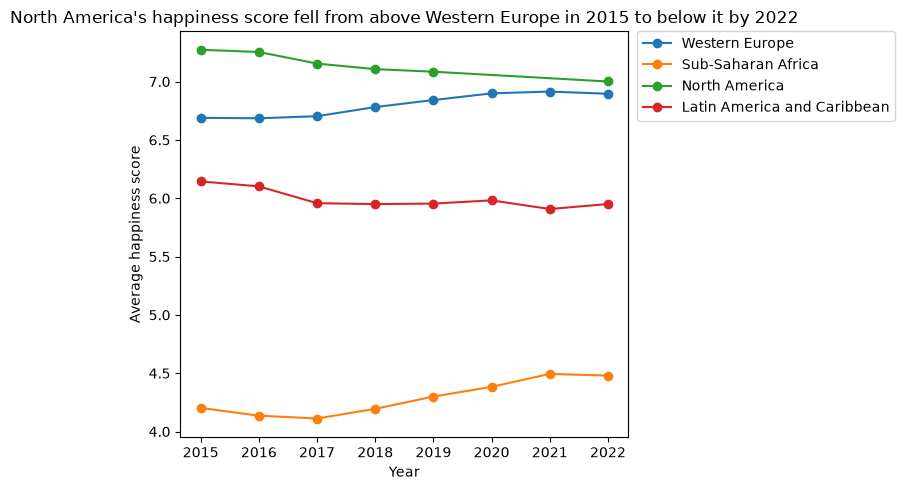

In [14]:
import matplotlib.pyplot as plt

regions_to_plot = ['Western Europe', 'Sub-Saharan Africa', 'North America', 'Latin America and Caribbean']

fig, ax = plt.subplots(figsize=(8,5))
for region in regions_to_plot:
    subset = combined[combined['region'] == region].groupby('year')['happiness_score'].mean()
    ax.plot(subset.index, subset.values, marker='o', label=region)

ax.set_xlabel('Year')
ax.set_ylabel('Average happiness score')
ax.set_title('North America\'s happiness score fell from above Western Europe in 2015 to below it by 2022')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig('../reports/a2_chart1.png', dpi=150, bbox_inches='tight')
plt.show()

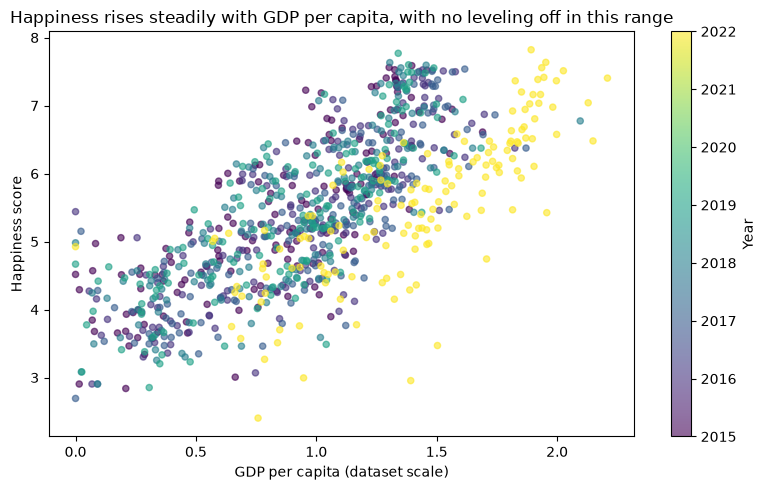

In [15]:
# Chart 2: does GDP per capita actually explain happiness, or is the relationship messier?
fig, ax = plt.subplots(figsize=(8,5))
scatter = ax.scatter(combined['gdp_per_capita'], combined['happiness_score'],
                      c=combined['year'], cmap='viridis', alpha=0.6, s=20)

ax.set_xlabel('GDP per capita (dataset scale)')
ax.set_ylabel('Happiness score')
ax.set_title('Happiness rises steadily with GDP per capita, with no leveling off in this range')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year')
plt.tight_layout()
plt.savefig('../reports/a2_chart2.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Check GDP per capita scale by year - something looks inconsistent
combined.groupby('year')['gdp_per_capita'].describe()[['mean','min','max']]

,mean,min,max
year,,,
2015,0.846137,0.0,1.690420
2016,0.953880,0.0,1.824270
2017,0.984718,0.0,1.870766
2018,0.891449,0.0,2.096000
2019,0.905147,0.0,1.684000
2020,NaN,NaN,NaN
2021,NaN,NaN,NaN
2022,1.410445,0.0,2.209000


In [17]:
# Save the cleaned, feature-engineered dataset
combined.to_csv('../data/processed/whr_cleaned.csv', index=False)
print("Saved. Final shape:", combined.shape)
print(combined.columns.tolist())

Saved. Final shape: (1230, 14)
['country', 'region', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption', 'year', 'region_avg_happiness', 'region_avg_gdp', 'happiness_vs_region', 'happiness_zscore']


## Task 6 — Cleaned Dataset and Report

The cleaned, feature-engineered dataset (region-filled, dtype-fixed, GDP scale issue flagged, groupby stats and z-score added) is saved to `data/processed/whr_cleaned.csv`.